In [1]:
import numpy as np
import pandas as pd
import proxUtil
#import sktime
import aeon
import os

#from sklearn.manifold import MDS
#from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score

from joblib import Parallel, delayed
import time

In [2]:
rootdir ='UCRArchive_2018'

thenames = []

for subdir, dirs, files in os.walk(rootdir):
    thename = subdir.replace(rootdir + '/','')
    if 'Missing' not in thename:
        thenames.extend([thename]) #break   

thenames = thenames[1:]

In [3]:
len(thenames)

128

In [4]:
# for each dataset:
    # for each distance metric:
        #1. compute distance matrix D
        #2. embed using MDS into 2-d (metric and non-metric)
        #3. compute kmeans clustering for k=num_classes. Compute scores--metric and nonmetric
        #4. Use D to compute LOF scores
        #5. Use kneighbors to classify.
        #6. compare outliers with misclassified points. Output confusion matrix.
        #7. Score: F1 score for confusion matrix.
        #8. Output of experiment: kmeans score, F1 score for outliers.

In [5]:
def getProxDist(traindata, trees=11, r=5, modelname="PF"):
    proxUtil.getProx(traindata,traindata,num_trees=trees, r=r, modelname=modelname)
    P,y_train = proxUtil.getProxArrays()
    P = proxUtil.SymmetrizeProx(P)
    D = (np.ones(P.shape) - P)**2
    return D,y_train

In [6]:
def getDistances(X_train,distance):
    D = np.zeros((X_train.shape[0],X_train.shape[0]))
    for i in range(X_train.shape[0]):
        jin = [j for j in range(X_train.shape[0]) if j > i] #only the upper-triangular distances are needed.
        for j in jin:
            #D[i][j] = distance(np.array([x for x in X_train.iloc[i][0]]), np.array([x for x in X_train.iloc[j][0]]))
            #D[i][j] = distance(np.array([x for x in X_train.iloc[i]]), np.array([x for x in X_train.iloc[j]]))
            D[i][j] = distance(np.array(X_train.iloc[i]), np.array(X_train.iloc[j]))
            
    D = D + D.transpose() # the distance should be symmetric.
    return D

In [7]:
def getMDS(D,Metric=False):
    Demb = MDS(n_components=2, metric=Metric, dissimilarity='precomputed', random_state=0)
    demb = Demb.fit_transform(D)
    return demb

In [8]:
def getKmeansAdjustedLabels(y_train):
    classes = np.unique(y_train)

    thelist = []
    for i in range(len(y_train)):
        if y_train[i] not in thelist:
            thelist.extend([y_train[i]])
        if len(thelist)==classes.shape[0]:
            break

    thedict = {thelist[i]: i for i in range(len(thelist))}
    kmeans_adjusted_labels = [thedict[y_train[i]] for i in range(len(y_train))]
    return kmeans_adjusted_labels

In [9]:
def getKmeansScore(X_emb,y,k):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_emb)
    preds = kmeans.predict(X_emb).tolist()
    print(preds)
    #print(y)
    y = getKmeansAdjustedLabels(y.tolist())
    print(y)
    rights = [1 for i in range(len(preds)) if preds[i]==y[i]]
    wrongs = [i for i in range(len(preds)) if preds[i]!=y[i]]
    score = len(rights)/len(preds)
    return score

In [10]:
def getLOFscores(D):
    LOF = LocalOutlierFactor(n_neighbors=5, metric="precomputed")
    preds = LOF.fit_predict(D) #1 is inlier, -1 is outlier.
    return preds

In [11]:
def getKNeighborsPreds(D, y_train,k=1):
    preds = []
    for i in range(D.shape[0]):
        row = D[i]
        idx = np.argpartition(row, k+1) #not "sorted." but first k indices are k nearest neighbors. (not counting self)
        classes = y_train[idx[1:k+1]]
        counts = np.bincount(classes)
        label = np.argmax(counts)
        preds.extend([label])
        
    return preds

def getPFpredictions():
    f0 = open("Predictions.txt")
    f1 = f0.read()
    preds = eval("np.array(" + f1 + ")")
    f0.close()
    return preds

In [12]:
def getF1OutlierScore(outliers, y_true, y_pred):
    # Each of these arguments should have the same length.
    # A point is considered to be an outlier if y_true[i] != y_pred[i].
    # A point is predicted to be an outlier if outliers[i] = -1.
    trues = [1 if y_pred[i]==y_true[i] else 0 for i in range(len(y_true))]
    accuracy = sum(trues)/len(trues)
    preds = [1 if outliers[i]==1 else 0 for i in range(len(outliers))]
    score = f1_score(trues, preds)
    return score, accuracy

In [13]:
def runPFGAPexperiment():
    mydict = {}
    #names = ["GunPoint", "ItalyPowerDemand", "ArrowHead"]
    for name in thenames[-2:]:
        filename = rootdir + '/' + name + '/' + name + "_TRAIN.tsv"
        D,y_train = getProxDist(filename, modelname=name)
        classes = np.unique(y_train)
        num_classes = len(classes)
        ## MDS embeddings
        #X_emb = getMDS(D)
        #X_emb_Metric = getMDS(D, Metric=True)
        ## kmeans scores on the embeddings
        #y_temp = y_train
        #kmeansScore = getKmeansScore(X_emb, y_temp, num_classes)
        #kmeansScore_metric = getKmeansScore(X_emb_Metric, y_temp, num_classes)
        # now we'll get f1 scores for "outliers" i.e. misclassified points.
        pred_outliers = getLOFscores(D) #5 nearest neighbors by default
        PFpreds = getPFpredictions()
        f1score, accuracy = getF1OutlierScore(pred_outliers, y_train, PFpreds)
        #mydict[name] = [kmeansScore, kmeansScore_metric, f1score, accuracy]
        mydict[name] = [f1score, accuracy]
        print("Finished " + name)
        print(mydict)
    
    return mydict

In [14]:
#results = runPFGAPexperiment()

In [15]:
def runExperiment(name):
    mydict = {}
    #names = ["load_gunpoint", "load_italy_power_demand", "load_arrow_head"]
    distances = ["dtw_distance", "ddtw_distance", "twe_distance", "wdtw_distance", "wddtw_distance",
                "euclidean_distance", "lcss_distance", "msm_distance", "erp_distance"]
    for i in range(1): #name in thenames:
        #exec("from sktime.datasets import " + name)
        #X_train, y_train = eval(name + "(split='TRAIN')")
        #y_train = y_train.astype(int)
        filename = rootdir + '/' + name + '/' + name + "_TRAIN.tsv"
        df = pd.read_csv(filename, sep='\t', header=None)
        if df.isnull().values.any():
            print(name + " contains nans: skipping")
            continue

        X_train = df[df.columns[1:]]
        y_train = df[df.columns[0]]
        classes = np.unique(y_train)
        num_classes = len(classes)
        er = ""
        try:
            timeout = 18*60 # 18 minutes
            t1 = time.time()
            for distance in distances:
                t2 = time.time()
                if t2-t1 > timeout:
                    print(name + ": Timeout")
                    break
                    
                #exec("from sktime.distances import " + distance)
                exec("from aeon.distances import " + distance)
                # pairwise distances:
                D = getDistances(X_train, eval(distance))
                ## MDS embeddings
                #X_emb = getMDS(D)
                #X_emb_Metric = getMDS(D, Metric=True)
                ## kmeans scores on the embeddings
                #if name=="load_gunpoint":
                #    y_temp = [0 if y_train[i]==2 else 1 for i in range(len(y_train))]
                #elif name=="load_italy_power_demand":
                #    y_temp = [y_train[i] - 1 for i in range(len(y_train))]
                #else:
                #    y_temp = y_train
                #kmeansScore = getKmeansScore(X_emb, y_temp, num_classes)
                #kmeansScore_metric = getKmeansScore(X_emb_Metric, y_temp, num_classes)
                # now we'll get f1 scores for "outliers" i.e. misclassified points.
                pred_outliers = getLOFscores(D) #5 nearest neighbors by default
                knnPreds = getKNeighborsPreds(D,y_train) #k=1 by default
                f1score, accuracy = getF1OutlierScore(pred_outliers, y_train, knnPreds)
                #mydict[name + "_" + distance] = [kmeansScore, kmeansScore_metric, f1score, accuracy]
                mydict[name + "_" + distance] = [f1score, accuracy]
                #print("Finished " + name + " " + distance)
        except:
            er += " (with errors: revisit this dataset)"
            
        
        print("Finished " + name + er)
        #print(mydict)
    
    return mydict

In [16]:
otherresults = Parallel(n_jobs=16)(delayed(runExperiment)(name) for name in thenames)

#otherresults = runExperiment()

PLAID contains nans: skipping
Finished CinCECGTorso
Finished FreezerRegularTrain
Finished GunPointMaleVersusFemale
Finished OliveOil
Finished MiddlePhalanxTW
StarLightCurves: Timeout
Finished StarLightCurves
DodgerLoopGame contains nans: skipping
SemgHandSubjectCh2: Timeout
Finished SemgHandSubjectCh2
Finished BeetleFly
Finished Herring
Finished ECGFiveDays
PigAirwayPressure: Timeout
Finished PigAirwayPressure
Strawberry: Timeout
Finished Strawberry
Finished ProximalPhalanxOutlineCorrect
Worms: Timeout
Finished Worms
AllGestureWiimoteY contains nans: skipping
MixedShapesSmallTrain: Timeout
Finished MixedShapesSmallTrain
SemgHandMovementCh2: Timeout
Finished SemgHandMovementCh2
Finished ToeSegmentation1
ShakeGestureWiimoteZ contains nans: skipping
Yoga: Timeout
Finished Yoga
Finished DistalPhalanxTW
Finished UMD
UWaveGestureLibraryZ: Timeout
Finished UWaveGestureLibraryZ
Finished ECG5000
Finished BME
DodgerLoopDay contains nans: skipping
GesturePebbleZ1 contains nans: skipping
Finished 

In [19]:
len(otherresults)

128

In [22]:
otherresults[0]

{'BirdChicken_dtw_distance': [0.7586206896551724, 0.8],
 'BirdChicken_ddtw_distance': [0.7999999999999999, 0.8],
 'BirdChicken_twe_distance': [0.888888888888889, 0.8],
 'BirdChicken_wdtw_distance': [0.7142857142857143, 0.8],
 'BirdChicken_wddtw_distance': [0.8235294117647058, 0.75],
 'BirdChicken_euclidean_distance': [0.8235294117647058, 0.7],
 'BirdChicken_lcss_distance': [0.75, 0.7],
 'BirdChicken_msm_distance': [0.8235294117647058, 0.7],
 'BirdChicken_erp_distance': [0.8235294117647058, 0.7]}

In [29]:
len([len(o) for o in otherresults if len(o)==9])

64

In [23]:
RealThing = {key: value for dict in otherresults for key,value in dict.items()}

In [24]:
len(RealThing)

698

In [30]:
RealThing2 = {key: value for dict in otherresults for key,value in dict.items() if len(dict)==9}

In [31]:
len(RealThing2)

576

In [33]:
resultDf = pd.DataFrame.from_dict(RealThing2)
#resultdf = pd.DataFrame.from_dict(otherresults)

In [34]:
resultDf.to_csv("Distances_PT_Results.csv")

In [ ]:
resultdf.shape

In [ ]:
# Get the arrowhead plot

In [70]:
P,y = proxUtil.getProxArrays()
P = proxUtil.SymmetrizeProx(P)
D = (np.ones(P.shape) - P)**1

In [71]:
x_trans = getMDS(D,Metric=True)

In [72]:
import matplotlib.pyplot as plt

In [73]:
X0 = np.array([x_trans[i] for i in range(x_trans.shape[0]) if y[i]==0]).transpose()
X1 = np.array([x_trans[i] for i in range(x_trans.shape[0]) if y[i]==1]).transpose()
X2 = np.array([x_trans[i] for i in range(x_trans.shape[0]) if y[i]==2]).transpose()
eX = [X0,X1,X2]

outs0 = np.array([sizes[i] for i in range(x_trans.shape[0]) if y[i]==0]).transpose()
outs1 = np.array([sizes[i] for i in range(x_trans.shape[0]) if y[i]==1]).transpose()
outs2 = np.array([sizes[i] for i in range(x_trans.shape[0]) if y[i]==2]).transpose()

In [74]:
sizes[5]=0

[2.71364490e+00 2.67990740e+00 6.98120905e-01 1.56213105e+00
 5.00745769e+00 5.23184969e-03 7.25871170e+00 5.62226770e-01
 1.46089881e+00 9.46462576e+01 3.40017949e+00 5.23184969e-03]


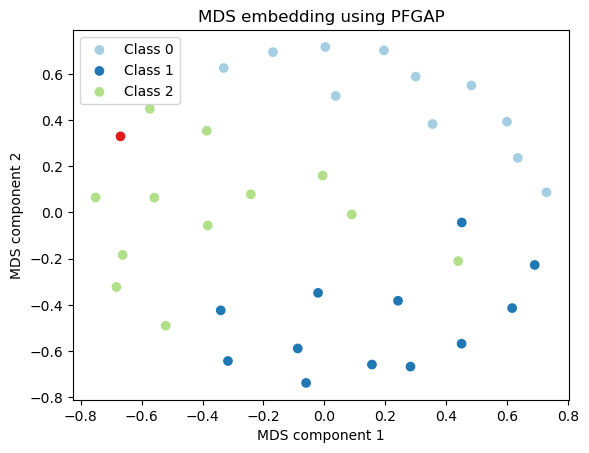

In [77]:
cmap = plt.cm.Paired
#plt.figure(figsize = (15,10))
for i in range(0,3):
    cmap1 = [i for j in range(eX[i].shape[1])]
    #if i==2:
    if y[np.argmax(sizes)] == i:
        print(outs0)
        #cmap1[5] = 5
        cmap1[np.argmax(eval("outs" + str(i)))] = 5
    plt.scatter(eX[i][0], eX[i][1], c=cmap(cmap1), 
                label="Class {:g}".format(i))
    
plt.legend()
plt.xlabel('MDS component 1')
plt.ylabel('MDS component 2')
plt.title('MDS embedding using PFGAP')
plt.show()

In [ ]:
f0 = open("Predictions_saved.txt")
f1 = f0.read()
preds = eval("np.array(" + f1 + ")")
f0.close()

In [25]:
sizes = [x*10 for x in proxUtil.getOutlierScores(P,y)]

In [30]:
sizes

[2.7136448988227073,
 8.667563582877197,
 0.0013906320155660117,
 2.6799073954359205,
 8.745309380732714,
 119.98824597018134,
 0.6981209046445179,
 6.331715533993767,
 0.0013274565497316843,
 1.5621310504680586,
 14.680121867925342,
 0.0008624745677088393,
 5.007457687993493,
 1.0855910328999103,
 0.0028560276935228014,
 0.005231849691845094,
 6.517689455779237,
 0.0001291548441109146,
 7.258711697323115,
 53.29517030446265,
 0.0012219169310823464,
 0.5622267703273723,
 8.160754015606472,
 0.0025452216856910164,
 1.4608988147361357,
 2.8602857419314116,
 0.00010685683541758871,
 94.64625758647456,
 0.24415693584318515,
 0.0003812037018082688,
 3.4001794943904393,
 0.24415693584318515,
 0.00010685683541758835,
 0.005231849691845094,
 9.16748521210494,
 0.0008262281585982173]

In [26]:
outs0 = np.array([sizes[i] for i in range(x_trans.shape[0]) if y[i]==0]).transpose()
outs1 = np.array([sizes[i] for i in range(x_trans.shape[0]) if y[i]==1]).transpose()
outs2 = np.array([sizes[i] for i in range(x_trans.shape[0]) if y[i]==2]).transpose()
Outs = [outs0,outs1,outs2]

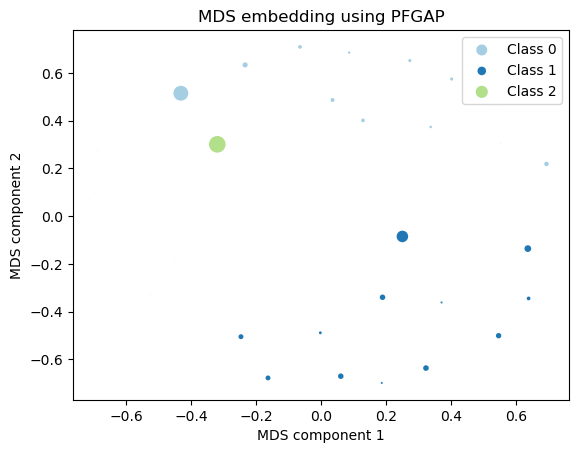

In [27]:
cmap = plt.cm.Paired
#plt.figure(figsize = (15,10))
for i in range(0,3):
    cmap1 = [i for j in range(eX[i].shape[1])]
    #if y[np.argmax(sizes)] == i:
    #    cmap1[np.argmax(eval("outs" + str(i)))] = 5
    plt.scatter(eX[i][0], eX[i][1], c=cmap(cmap1), s=Outs[i], 
                label="Class {:g}".format(i))
    
plt.legend()
plt.xlabel('MDS component 1')
plt.ylabel('MDS component 2')
plt.title('MDS embedding using PFGAP')
plt.show()